In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import duckdb

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

In [142]:
Credit_2026_sql = duckdb.sql("SELECT * FROM '2026-05-04_transaction_download.csv'")

In [143]:
credit_df = Credit_2026_sql.df()
credit_df

,Transaction Date,Posted Date,Card No.,Description,Category,Debit,Credit
0,2025-12-29,2025-12-31,3968,TASTY POT,Dining,71.36,NaN
1,2025-12-29,2025-12-30,3968,SFMOMA MUSEUMSTORE,Entertainment,14.95,NaN
2,2025-12-28,2025-12-29,3968,AIRGARAGE PARKING,Gas/Automotive,7.50,NaN
3,2025-12-28,2025-12-29,3968,OPENAI *CHATGPT SUBSCR,Merchandise,20.00,NaN
4,2025-12-27,2025-12-29,3968,TRADING CARD STORE,Merchandise,15.15,NaN
...,...,...,...,...,...,...,...
709,2025-01-02,2025-01-03,3968,LAZ PARKING M18611-SKI,Gas/Automotive,7.00,NaN
710,2025-01-02,2025-01-03,3968,SQ *SEKAIDO,Merchandise,15.78,NaN
711,2025-01-01,2025-01-02,3968,YERBA BUENA ICE SKATIN,Entertainment,21.00,NaN
712,2024-12-31,2025-01-02,3968,"D20 GAMES, LLC",Merchandise,15.48,NaN


In [144]:
credit_df["Category"].value_counts()

Category
Dining                 287
Merchandise            187
Gas/Automotive          87
Other Services          56
Payment/Credit          32
Entertainment           19
Internet                14
Phone/Cable             12
Other                    7
Health Care              5
Other Travel             5
Fee/Interest Charge      2
Insurance                1
Name: count, dtype: int64

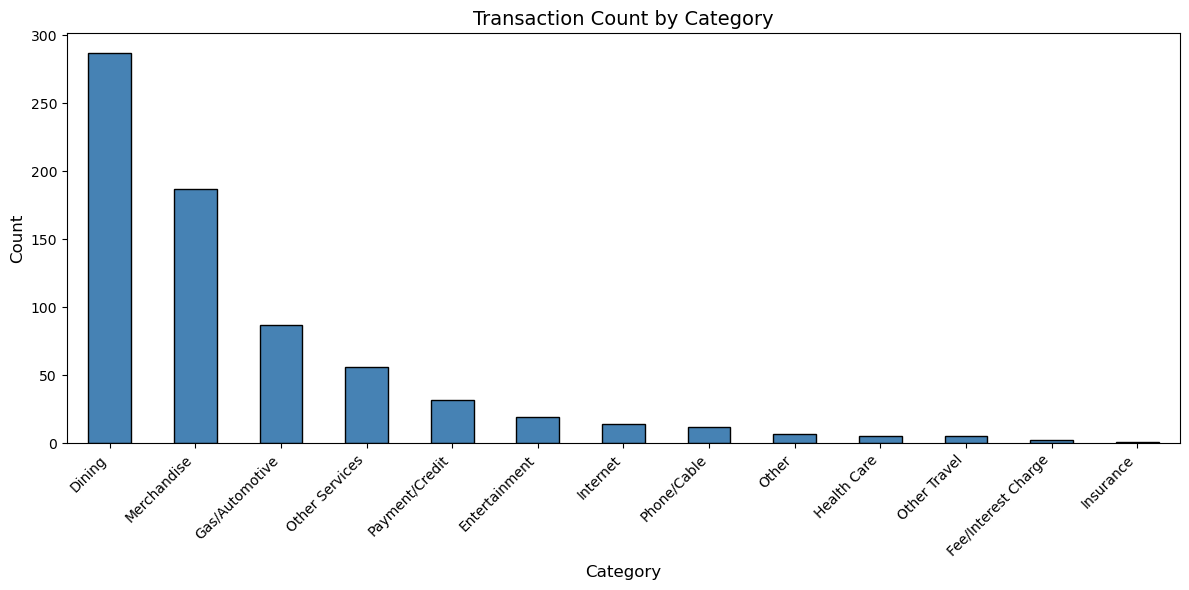

In [145]:
fig, ax = plt.subplots(figsize=(12, 6))

credit_df["Category"].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')

ax.set_title("Transaction Count by Category", fontsize=14)
ax.set_xlabel("Category", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Based on my spending habits from last year, I spent majority of my credit on eating out. Second I spent a lot of my creditcard on merchandise. Moreover, I care about what I used my card for and not what I paid for the credit. 

In [146]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction Date  714 non-null    datetime64[us]
 1   Posted Date       714 non-null    datetime64[us]
 2   Card No.          714 non-null    int64         
 3   Description       714 non-null    object        
 4   Category          714 non-null    object        
 5   Debit             679 non-null    float64       
 6   Credit            35 non-null     float64       
dtypes: datetime64[us](2), float64(2), int64(1), object(2)
memory usage: 39.2+ KB


In [147]:
credit_clean_df = credit_df[credit_df['Category'] != "Payment/Credit"]

credit_clean_df.groupby("Category")["Debit"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
Dining,287.0,20.86,26.36,0.40,7.04,13.80,20.62,226.55
Entertainment,19.0,31.55,41.15,8.50,12.48,15.00,22.81,173.05
Fee/Interest Charge,2.0,8.52,9.04,2.12,5.32,8.52,11.71,14.91
Gas/Automotive,87.0,6.23,5.90,1.00,2.35,4.35,8.00,32.75
Health Care,5.0,14.82,8.86,7.38,8.15,10.86,19.66,28.04
Insurance,1.0,6.92,NaN,6.92,6.92,6.92,6.92,6.92
Internet,14.0,18.69,8.38,2.00,14.14,19.99,19.99,35.62
Merchandise,184.0,23.38,17.80,1.49,10.97,19.66,28.70,96.10
Other,7.0,438.31,290.68,11.50,233.16,521.09,644.55,780.14


To further investigate my spending, I want to explore how much I have been spendin on average per month. I'm also going to plot and see the categories seperately and see how each category compare to one another.

In [148]:
credit_clean_df = credit_df[credit_df['Category'] != "Payment/Credit"].copy()
credit_clean_df['Date'] = pd.to_datetime(credit_clean_df['Transaction Date'])
credit_clean_df['Month'] = credit_clean_df["Date"].dt.to_period("M")

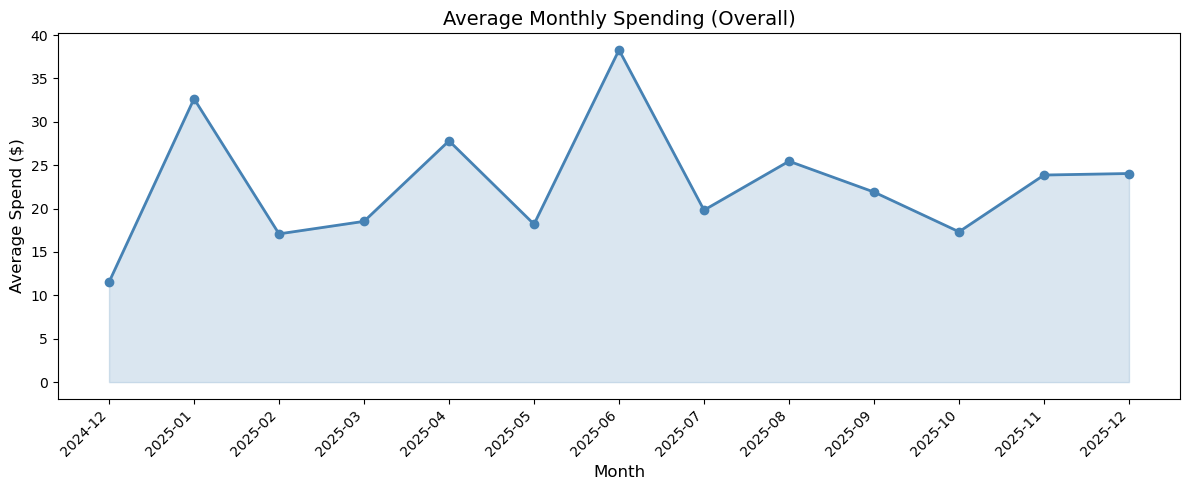

In [149]:
monthly_avg = credit_clean_df.groupby('Month')['Debit'].mean().reset_index()
monthly_avg['Month'] = monthly_avg['Month'].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_avg['Month'], monthly_avg['Debit'], marker='o', color='steelblue', linewidth=2)
ax.fill_between(monthly_avg['Month'], monthly_avg['Debit'], alpha=0.2, color='steelblue')

ax.set_title("Average Monthly Spending (Overall)", fontsize=14)
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Average Spend ($)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

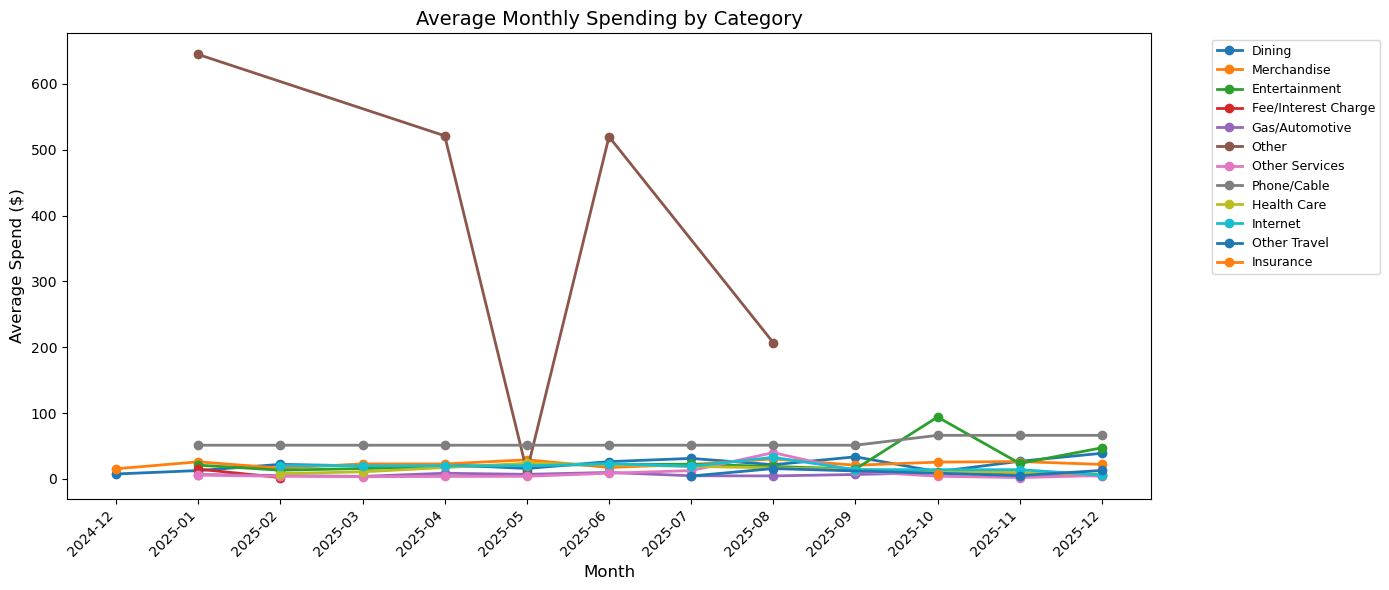

In [150]:
monthly_cat = credit_clean_df.groupby(['Month', 'Category'])['Debit'].mean().reset_index()
monthly_cat['Month'] = monthly_cat['Month'].astype(str)

categories = monthly_cat['Category'].unique()

fig, ax = plt.subplots(figsize=(14, 6))

for cat in categories:
    cat_data = monthly_cat[monthly_cat['Category'] == cat]
    ax.plot(cat_data['Month'], cat_data['Debit'], marker='o', label=cat, linewidth=2)

ax.set_title("Average Monthly Spending by Category", fontsize=14)
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Average Spend ($)", fontsize=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [151]:
category_other = credit_df[credit_df["Category"] == 'Other']

As we can see these are irrelavant. The Returned Mobile ACH Payments are when I somehow didn't have enough money in the bank at the time thus returning the payment and charging my card again.


To further investigate I would like to see the total sum of how much I was spending per month

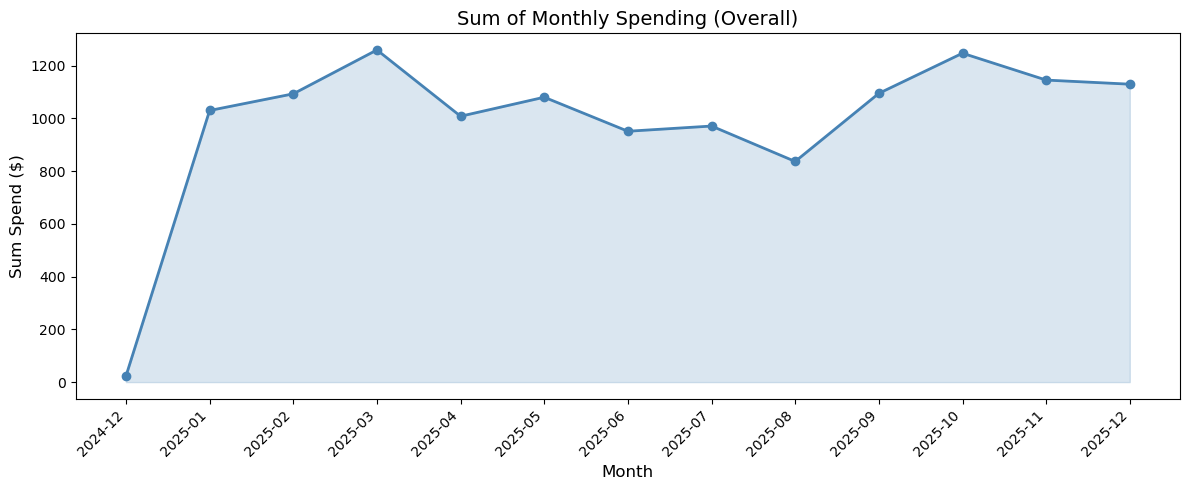

In [152]:
credit_clean_df = credit_clean_df[credit_clean_df["Category"] != "Other"]
monthly_sum = credit_clean_df.groupby('Month')['Debit'].sum().reset_index()
monthly_sum['Month'] = monthly_avg['Month'].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_sum['Month'], monthly_sum['Debit'], marker='o', color='steelblue', linewidth=2)
ax.fill_between(monthly_sum['Month'], monthly_sum['Debit'], alpha=0.2, color='steelblue')

ax.set_title("Sum of Monthly Spending (Overall)", fontsize=14)
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Sum Spend ($)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [153]:
Janurary_2025 = credit_clean_df[credit_clean_df['Month'] == '2025-01']

In [154]:
print(Janurary_2025.groupby('Category')['Debit'].describe())
print("-" * 100)
print(Janurary_2025.groupby('Category')['Debit'].sum())

                     count       mean        std    min      25%    50%  \
Category                                                                  
Dining                38.0  12.785526  12.537629   0.99   5.2375  10.77   
Entertainment          1.0  21.000000        NaN  21.00  21.0000  21.00   
Fee/Interest Charge    1.0  14.910000        NaN  14.91  14.9100  14.91   
Gas/Automotive        12.0   6.772500   5.740691   1.00   1.7400   6.30   
Merchandise           14.0  26.035000  15.482608  11.14  18.1175  20.49   
Other Services         2.0   5.800000   3.889087   3.05   4.4250   5.80   
Phone/Cable            1.0  51.250000        NaN  51.25  51.2500  51.25   

                         75%    max  
Category                             
Dining               16.9800  76.75  
Entertainment        21.0000  21.00  
Fee/Interest Charge  14.9100  14.91  
Gas/Automotive        8.0000  21.00  
Merchandise          28.1675  60.18  
Other Services        7.1750   8.55  
Phone/Cable         

In [155]:
March_2025 = credit_clean_df[credit_clean_df["Month"] == "2025-3"]
print(March_2025.groupby("Category")["Debit"].describe())
print("-" * 100)
print(March_2025.groupby("Category")["Debit"].sum())

                count       mean        std    min      25%     50%     75%  \
Category                                                                      
Dining           32.0  19.788438  23.143644   0.80   7.0050  16.290  20.835   
Gas/Automotive    6.0   3.916667   2.419022   1.10   2.5125   3.175   5.600   
Health Care       1.0  10.860000        NaN  10.86  10.8600  10.860  10.860   
Internet          1.0  19.990000        NaN  19.99  19.9900  19.990  19.990   
Merchandise      22.0  22.901818  26.034168   1.60   6.9825  10.645  21.875   
Other Services    5.0   3.480000   2.711457   1.40   2.0000   2.000   4.000   
Phone/Cable       1.0  51.250000        NaN  51.25  51.2500  51.250  51.250   

                   max  
Category                
Dining          111.77  
Gas/Automotive    7.35  
Health Care      10.86  
Internet         19.99  
Merchandise      90.37  
Other Services    8.00  
Phone/Cable      51.25  
---------------------------------------------------------------

In [156]:
total_spending = credit_clean_df['Debit'].sum()

category_ratio = (credit_clean_df.groupby('Category')['Debit'].sum() / total_spending * 100).round(2)

category_ratio

Category
Dining                 46.50
Entertainment           4.66
Fee/Interest Charge     0.13
Gas/Automotive          4.21
Health Care             0.58
Insurance               0.05
Internet                2.03
Merchandise            33.42
Other Services          2.96
Other Travel            0.34
Phone/Cable             5.13
Name: Debit, dtype: float64

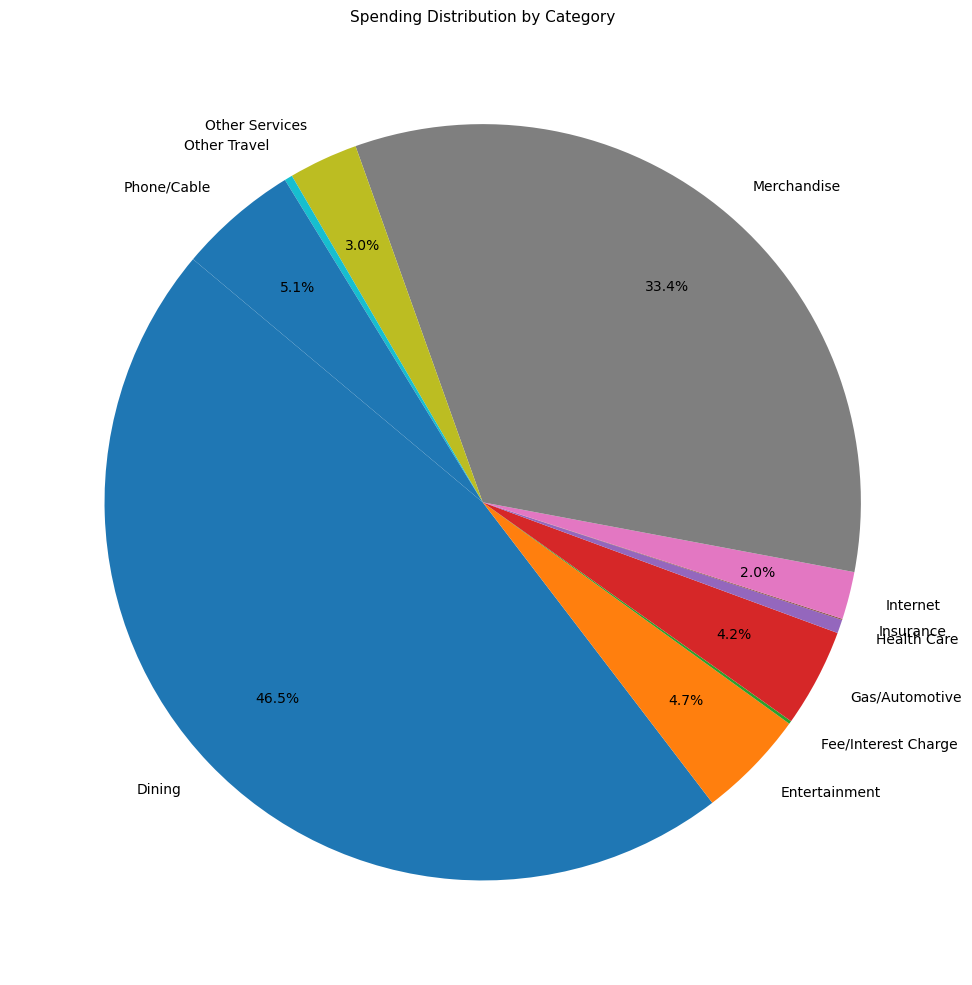

In [157]:
fig, ax = plt.subplots(figsize=(10, 10))

# Only show label on slices > 2%
def autopct_filter(pct):
    return f'{pct:.1f}%' if pct > 2 else ''

category_ratio.plot(
    kind='pie',
    ax=ax,
    autopct=autopct_filter,
    startangle=140,
    pctdistance=0.75
)

ax.set_title("Spending Distribution by Category", fontsize=11)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

Now to run a Model to see if its predicted that my expenses will go up or not

In [160]:
credit_clean_df = credit_df[credit_df['Category'] != "Payment/Credit"].copy()
credit_clean_df = credit_clean_df.drop(columns=['Credit'])
credit_clean_df = credit_clean_df.dropna(subset=['Debit'])

label = LabelEncoder()
credit_clean_df['Category_encoded'] = label.fit_transform(credit_clean_df['Category'])

X = credit_clean_df[['Category_encoded']]
y = credit_clean_df['Debit']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

RandomForestRegressor(random_state=42)

In [161]:
y_pred = model.predict(X)

print(f"MAE: ${mean_absolute_error(y, y_pred):.2f}")
print(f"R² Score: {r2_score(y, y_pred):.2f}")

MAE: $14.49
R² Score: 0.61


In [162]:
results_df = pd.DataFrame({
    'Category': credit_clean_df['Category'],
    'Actual': y,
    'Predicted': y_pred
})

category_summary = results_df.groupby('Category').agg(
    Actual_Avg=('Actual', 'mean'),
    Predicted_Avg=('Predicted', 'mean'),
    Total_Spend=('Actual', 'sum'),
    Transaction_Count=('Actual', 'count')
).round(2).sort_values('Total_Spend', ascending=False)

print(category_summary)

                     Actual_Avg  Predicted_Avg  Total_Spend  Transaction_Count
Category                                                                      
Dining                    20.86          20.79      5987.27                287
Merchandise               23.38          23.50      4302.84                184
Other                    438.31         434.63      3068.16                  7
Phone/Cable               55.00          55.19       660.00                 12
Entertainment             31.55          31.35       599.49                 19
Gas/Automotive             6.23           6.14       541.66                 87
Other Services             6.81           7.00       381.12                 56
Internet                  18.69          18.51       261.63                 14
Health Care               14.82          15.13        74.09                  5
Other Travel               8.66           8.47        43.30                  5
Fee/Interest Charge        8.52          12.92      

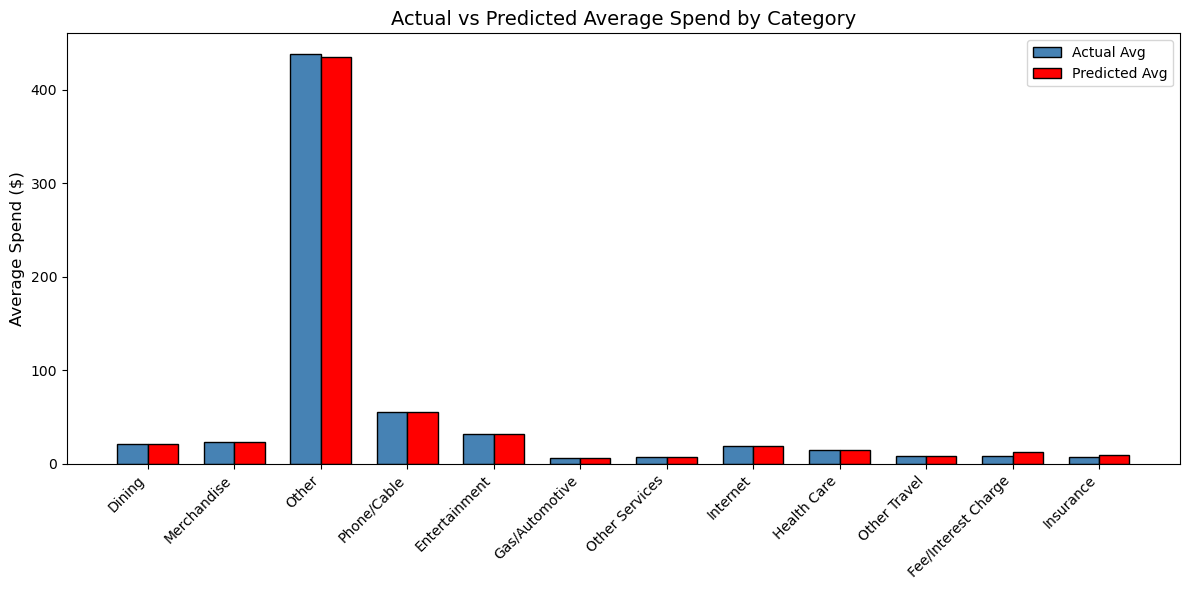

In [172]:
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(category_summary))
width = 0.35

ax.bar([i - width/2 for i in x], category_summary['Actual_Avg'], 
       width, label='Actual Avg', color='steelblue', edgecolor='black')
ax.bar([i + width/2 for i in x], category_summary['Predicted_Avg'], 
       width, label='Predicted Avg', color='red', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(category_summary.index, rotation=45, ha='right')
ax.set_title("Actual vs Predicted Average Spend by Category", fontsize=14)
ax.set_ylabel("Average Spend ($)", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

In [171]:
category_mapping = dict(zip(label.classes_, label.transform(label.classes_)))
print(category_mapping)

# Predict spend for Dining
dining_encoded = label.transform(['Dining'])[0]
predicted_spend = model.predict(pd.DataFrame([[dining_encoded]], columns=['Category_encoded'])) #pd.DataFrame to help the consistency of the element
print(f"Predicted Dining spend: ${predicted_spend[0]:.2f}")

{'Dining': np.int64(0), 'Entertainment': np.int64(1), 'Fee/Interest Charge': np.int64(2), 'Gas/Automotive': np.int64(3), 'Health Care': np.int64(4), 'Insurance': np.int64(5), 'Internet': np.int64(6), 'Merchandise': np.int64(7), 'Other': np.int64(8), 'Other Services': np.int64(9), 'Other Travel': np.int64(10), 'Phone/Cable': np.int64(11)}
Predicted Dining spend: $20.79
